# NLP Workshop: Text Preprocessing and Representation

This notebook covers the full pipeline from raw text to numerical representations ready for machine learning. We'll work through:

1. **Text Preprocessing** — cleaning, tokenization, stopword removal, stemming, and lemmatization
2. **Text Representation** — Bag of Words, TF-IDF, and word embeddings
3. **Mini-project** — building a baseline classifier using TF-IDF + Logistic Regression

We'll use the [AG News](https://huggingface.co/datasets/fancyzhx/ag_news) dataset from Hugging Face — a 4-class news topic classification dataset with 120,000 training examples.

---

**Estimated time:** ~2.5 hours  
**Prerequisites:** Basic Python, familiarity with pandas

## Part 0 — Setup

Install the libraries we need. Run this cell once, then restart the kernel if prompted.

In [2]:
# Install required packages
# datasets  : Hugging Face library for loading benchmark datasets
# nltk      : classic NLP toolkit (tokenizers, stemmers, stopwords)
# spacy     : industrial-strength NLP with fast tokenization and lemmatization
# scikit-learn : vectorizers and ML models
# gensim    : Word2Vec and GloVe loading

!pip install -q datasets nltk spacy scikit-learn gensim
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 67.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [1]:
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
import spacy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from collections import Counter
from datasets import load_dataset

from nltk.tokenize import word_tokenize, sent_tokenize, RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import TruncatedSVD

from gensim.models import Word2Vec

# Download NLTK data bundles we'll use throughout the notebook
nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',   quiet=True)
nltk.download('stopwords',   quiet=True)
nltk.download('wordnet',     quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Load the spaCy English model (small, fast)
nlp = spacy.load('en_core_web_sm')

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Part 1 — Load the Dataset

AG News contains news articles across four categories:

| Label | Category |
|-------|----------|
| 0 | World |
| 1 | Sports |
| 2 | Business |
| 3 | Sci/Tech |

We'll work with a manageable 5,000-sample slice during the preprocessing exercises, then use more data for the classifier.

In [2]:
# Load from Hugging Face Hub. The first call downloads and caches automatically.
dataset = load_dataset('fancyzhx/ag_news')

# Convert to pandas DataFrames for familiar manipulation
train_df = dataset['train'].to_pandas()
test_df  = dataset['test'].to_pandas()

label_names = ['World', 'Sports', 'Business', 'Sci/Tech']
train_df['label_name'] = train_df['label'].map(lambda x: label_names[x])
test_df['label_name']  = test_df['label'].map(lambda x: label_names[x])

print(f'Training samples : {len(train_df):,}')
print(f'Test samples     : {len(test_df):,}')
train_df.head(3)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Training samples : 120,000
Test samples     : 7,600


,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business


In [3]:
# Take a smaller working slice for the preprocessing section
# Stratified: 1,250 examples per class so classes stay balanced
sample_df = (
    train_df
    .groupby('label', group_keys=False)
    .apply(lambda x: x.sample(1250, random_state=42))
    .reset_index(drop=True)
)

print(f'Working sample size: {len(sample_df):,}')
print(sample_df['label_name'].value_counts())

Working sample size: 5,000
label_name
World       1250
Sports      1250
Business    1250
Sci/Tech    1250
Name: count, dtype: int64


---
## Part 2 — Text Preprocessing Pipeline

Raw text is noisy. Before feeding it to any model, we typically need to standardize it. The steps are often applied in this order:

```
raw text
   -> lowercase + clean HTML/URLs
   -> remove punctuation / special characters
   -> tokenize
   -> remove stopwords
   -> stem  OR  lemmatize
   -> rejoin into cleaned string
```

Not every step is always needed — the right pipeline depends on the task. We'll see that in action below.

### 2.1 Lowercasing and Cleaning

In [4]:
# A typical news article headline may include HTML entities, URLs, and odd whitespace.
# Let's look at a raw example first.

raw_example = train_df['text'].iloc[0]
print('RAW TEXT:')
print(raw_example)
print()

def basic_clean(text: str) -> str:
    """
    Apply the most fundamental cleaning steps:
      - lowercase everything
      - strip URLs
      - strip HTML tags
      - collapse multiple whitespace characters
    """
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # remove URLs
    text = re.sub(r'<[^>]+>', '', text)                  # remove HTML tags
    text = re.sub(r'\s+', ' ', text).strip()             # collapse whitespace
    return text

cleaned = basic_clean(raw_example)
print('AFTER BASIC CLEANING:')
print(cleaned)

RAW TEXT:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

AFTER BASIC CLEANING:
wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street's dwindling\band of ultra-cynics, are seeing green again.


### 2.2 Tokenization

Tokenization splits a string into units (tokens). The right granularity depends on the task:

- **Word-level** — most common; one token per word
- **Sentence-level** — useful for tasks that need context across sentences (e.g. summarization)
- **Subword-level** — used by modern transformers (BERT, GPT); handles unknown words gracefully

In [5]:
sample_sentence = "The Fed raised interest rates by 0.25%, surprising many Wall Street analysts."

# --- Word-level tokenization ---
# nltk.word_tokenize handles contractions, punctuation, and edge cases well
word_tokens = word_tokenize(sample_sentence)
print('Word tokens (NLTK):')
print(word_tokens)
print()

# --- Sentence-level tokenization ---
multi_sentence = (
    "Apple reported record earnings. The stock jumped 5% after hours. "
    "Analysts had expected a more modest gain."
)
sent_tokens = sent_tokenize(multi_sentence)
print('Sentence tokens (NLTK):')
for i, s in enumerate(sent_tokens):
    print(f'  [{i}] {s}')
print()

# --- Regex-based tokenizer ---
# Keeps only alphabetic sequences, discarding numbers and punctuation entirely.
# Useful when you want a very clean token stream.
re_tokenizer = RegexpTokenizer(r'[a-zA-Z]+')
re_tokens = re_tokenizer.tokenize(sample_sentence)
print('Regex tokens (letters only):')
print(re_tokens)

Word tokens (NLTK):
['The', 'Fed', 'raised', 'interest', 'rates', 'by', '0.25', '%', ',', 'surprising', 'many', 'Wall', 'Street', 'analysts', '.']

Sentence tokens (NLTK):
  [0] Apple reported record earnings.
  [1] The stock jumped 5% after hours.
  [2] Analysts had expected a more modest gain.

Regex tokens (letters only):
['The', 'Fed', 'raised', 'interest', 'rates', 'by', 'surprising', 'many', 'Wall', 'Street', 'analysts']


### 2.3 Stopword Removal

Stopwords are high-frequency words ("the", "is", "at") that carry little semantic weight for most classification tasks. Removing them reduces feature space size and noise.

In [6]:
stop_words = set(stopwords.words('english'))

print(f'Total English stopwords in NLTK: {len(stop_words)}')
print('Sample stopwords:', sorted(list(stop_words))[:20])
print()

# Apply stopword removal to our sample
tokens = word_tokenize(sample_sentence.lower())
filtered = [t for t in tokens if t not in stop_words and t.isalpha()]

print('Before stopword removal:', tokens)
print('After  stopword removal:', filtered)

Total English stopwords in NLTK: 198
Sample stopwords: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']

Before stopword removal: ['the', 'fed', 'raised', 'interest', 'rates', 'by', '0.25', '%', ',', 'surprising', 'many', 'wall', 'street', 'analysts', '.']
After  stopword removal: ['fed', 'raised', 'interest', 'rates', 'surprising', 'many', 'wall', 'street', 'analysts']


In [7]:
# You can extend or customize the stopword list for your domain.
# For example, in news classification the word "reuters" appears in many articles
# but doesn't help distinguish topics.

custom_stopwords = stop_words | {'reuters', 'said', 'say', 'says', 'ap', 'afp'}
print(f'Extended stopword list size: {len(custom_stopwords)}')

Extended stopword list size: 204


### 2.4 Stemming vs. Lemmatization

Both techniques reduce a word to a base form, but they differ in approach:

| | Stemming | Lemmatization |
|---|---|---|
| Method | Rule-based suffix stripping | Dictionary lookup |
| Output | May not be a real word | Always a valid word |
| Speed | Fast | Slower |
| Example | "running" → "run" | "running" → "run" |
| Example | "studies" → "studi" | "studies" → "study" |

In [8]:
porter   = PorterStemmer()
snowball = SnowballStemmer('english')
lemmatizer = WordNetLemmatizer()

test_words = ['running', 'studies', 'better', 'flies', 'generously', 'wolves', 'banking']

print(f'{"Word":<15} {"Porter":<15} {"Snowball":<15} {"Lemma":<15}')
print('-' * 60)
for word in test_words:
    print(
        f'{word:<15}'
        f'{porter.stem(word):<15}'
        f'{snowball.stem(word):<15}'
        f'{lemmatizer.lemmatize(word):<15}'
    )

Word            Porter          Snowball        Lemma          
------------------------------------------------------------
running        run            run            running        
studies        studi          studi          study          
better         better         better         better         
flies          fli            fli            fly            
generously     gener          generous       generously     
wolves         wolv           wolv           wolf           
banking        bank           bank           banking        


In [10]:
import nltk
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# WordNet lemmatizer needs a POS tag for best results.
# Without it, it defaults to noun (which is why "running" stays "running" above).

from nltk import pos_tag
from nltk.corpus import wordnet

def get_wordnet_pos(treebank_tag: str) -> str:
    """Map NLTK POS tags to WordNet POS constants."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default

sentence = "The analysts were analyzing the analyzed data carefully."
tokens   = word_tokenize(sentence)
tagged   = pos_tag(tokens)

lemmas   = [
    lemmatizer.lemmatize(token, get_wordnet_pos(tag))
    for token, tag in tagged
]

print('Tokens:', tokens)
print('Lemmas:', lemmas)

Tokens: ['The', 'analysts', 'were', 'analyzing', 'the', 'analyzed', 'data', 'carefully', '.']
Lemmas: ['The', 'analyst', 'be', 'analyze', 'the', 'analyze', 'data', 'carefully', '.']


### 2.5 spaCy-based Preprocessing

spaCy processes a document in a single pass and gives you tokens, POS tags, lemmas, named entities, and dependency arcs all at once. This makes it efficient for production pipelines.

In [11]:
doc = nlp("Apple's CEO Tim Cook announced record iPhone sales in Q3 2024.")

print(f'{'Token':<15} {'Lemma':<15} {'POS':<10} {'Is Stop':<10} {'Is Punct':<10}')
print('-' * 60)
for token in doc:
    print(
        f'{token.text:<15}'
        f'{token.lemma_:<15}'
        f'{token.pos_:<10}'
        f'{str(token.is_stop):<10}'
        f'{str(token.is_punct):<10}'
    )

print()
print('Named Entities:')
for ent in doc.ents:
    print(f'  {ent.text!r:<25} -> {ent.label_}')

Token           Lemma           POS        Is Stop    Is Punct  
------------------------------------------------------------
Apple          Apple          PROPN     False     False     
's             's             PART      True      False     
CEO            CEO            PROPN     False     False     
Tim            Tim            PROPN     False     False     
Cook           Cook           PROPN     False     False     
announced      announce       VERB      False     False     
record         record         NOUN      False     False     
iPhone         iPhone         PROPN     False     False     
sales          sale           NOUN      False     False     
in             in             ADP       True      False     
Q3             Q3             PROPN     False     False     
2024           2024           NUM       False     False     
.              .              PUNCT     False     True      

Named Entities:
  'Apple'                   -> ORG
  'Tim Cook'                -

### 2.6 Building a Reusable Preprocessing Pipeline

Now we combine everything into a single function and apply it to the AG News dataset.

In [12]:
STOPWORDS = set(stopwords.words('english')) | {'reuters', 'said', 'say', 'says', 'ap', 'afp'}
_stemmer    = PorterStemmer()
_lemmatizer = WordNetLemmatizer()


def preprocess(
    text: str,
    remove_stopwords: bool = True,
    method: str = 'lemma',       # 'stem', 'lemma', or 'none'
    min_token_len: int = 2
) -> str:
    """
    Full text preprocessing pipeline.

    Parameters
    ----------
    text             : raw input string
    remove_stopwords : whether to drop common function words
    method           : normalization strategy — 'stem', 'lemma', or 'none'
    min_token_len    : discard tokens shorter than this (catches stray letters)

    Returns
    -------
    Preprocessed string with tokens joined by spaces.
    """
    # Step 1: lowercase and clean
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)   # keep only lowercase letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 2: tokenize
    tokens = text.split()

    # Step 3: filter short tokens and (optionally) stopwords
    tokens = [t for t in tokens if len(t) >= min_token_len]
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOPWORDS]

    # Step 4: normalize
    if method == 'stem':
        tokens = [_stemmer.stem(t) for t in tokens]
    elif method == 'lemma':
        tokens = [_lemmatizer.lemmatize(t) for t in tokens]
    # 'none' -> no normalization

    return ' '.join(tokens)


# Quick test
raw = "The Fed's officials are expected to raise interest rates at their upcoming meeting."
print('Raw:  ', raw)
print('Lemma:', preprocess(raw, method='lemma'))
print('Stem: ', preprocess(raw, method='stem'))
print('None: ', preprocess(raw, method='none'))

Raw:   The Fed's officials are expected to raise interest rates at their upcoming meeting.
Lemma: fed official expected raise interest rate upcoming meeting
Stem:  fed offici expect rais interest rate upcom meet
None:  fed officials expected raise interest rates upcoming meeting


In [13]:
# Apply preprocessing to the sample dataframe.
# We create a separate column for each strategy so we can compare them.

print('Preprocessing sample_df (this takes ~30 seconds)...')

sample_df['clean_lemma'] = sample_df['text'].apply(lambda t: preprocess(t, method='lemma'))
sample_df['clean_stem']  = sample_df['text'].apply(lambda t: preprocess(t, method='stem'))
sample_df['clean_none']  = sample_df['text'].apply(lambda t: preprocess(t, method='none'))

# Spot-check one row
idx = 10
print(f'\nOriginal : {sample_df["text"].iloc[idx]}')
print(f'Lemma    : {sample_df["clean_lemma"].iloc[idx]}')
print(f'Stem     : {sample_df["clean_stem"].iloc[idx]}')

Preprocessing sample_df (this takes ~30 seconds)...

Original : Kite festival begins as prelude to 350th anniversary of Taj Agra, Sep 27. (PTI):A kite festival today began on the banks of the Yamuna river behind the Taj Mahal as a prelude to the 350th anniversary celebrations of the world-famous monument opening this evening.
Lemma    : kite festival begin prelude th anniversary taj agra sep pti kite festival today began bank yamuna river behind taj mahal prelude th anniversary celebration world famous monument opening evening
Stem     : kite festiv begin prelud th anniversari taj agra sep pti kite festiv today began bank yamuna river behind taj mahal prelud th anniversari celebr world famou monument open even


### 2.7 Comparing Preprocessing Strategies

Let's measure vocabulary size and average document length for each strategy. Smaller vocabularies mean lower-dimensional feature spaces, which often speeds up training.

In [14]:
def vocabulary_stats(series: pd.Series, label: str):
    all_tokens  = ' '.join(series).split()
    vocab       = set(all_tokens)
    avg_len     = series.apply(lambda x: len(x.split())).mean()
    print(f'{label:<20} vocab={len(vocab):>6,}   avg tokens/doc={avg_len:>5.1f}')

vocabulary_stats(sample_df['text'],         'Raw (original)')
vocabulary_stats(sample_df['clean_none'],   'Cleaned, no norm')
vocabulary_stats(sample_df['clean_lemma'],  'Cleaned + lemma')
vocabulary_stats(sample_df['clean_stem'],   'Cleaned + stem')

Raw (original)       vocab=31,744   avg tokens/doc= 37.9
Cleaned, no norm     vocab=17,074   avg tokens/doc= 24.9
Cleaned + lemma      vocab=15,120   avg tokens/doc= 24.9
Cleaned + stem       vocab=11,980   avg tokens/doc= 24.9


---
## Part 3 — Text Representation

ML models require numbers, not strings. Here we convert preprocessed text into numerical feature vectors using three approaches:

| Method | Captures | Loses |
|--------|---------|-------|
| Bag of Words | Word presence/count | Word order, context |
| TF-IDF | Word importance per doc | Word order, context |
| Word2Vec | Semantic similarity | Document-level context |

### 3.1 Bag of Words (CountVectorizer)

In [15]:
# CountVectorizer builds a vocabulary from the training corpus
# and represents each document as a vector of word counts.

bow_vectorizer = CountVectorizer(
    max_features=10_000,  # keep only the 10k most frequent terms
    min_df=3,             # ignore terms appearing in fewer than 3 documents
    ngram_range=(1, 2)    # include unigrams and bigrams
)

# Fit on training text, then transform
X_bow = bow_vectorizer.fit_transform(sample_df['clean_lemma'])

print(f'BoW matrix shape  : {X_bow.shape}')   # (n_docs, vocab_size)
print(f'Matrix sparsity   : {1 - X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]):.3%}')
print()

# Top 20 most frequent terms
feature_names = bow_vectorizer.get_feature_names_out()
word_counts   = X_bow.sum(axis=0).A1
top_idx       = word_counts.argsort()[-20:][::-1]
print('Top 20 terms by frequency:')
print([feature_names[i] for i in top_idx])

BoW matrix shape  : (5000, 9009)
Matrix sparsity   : 99.749%

Top 20 terms by frequency:
['new', 'year', 'lt', 'gt', 'quot', 'company', 'two', 'first', 'lt gt', 'world', 'game', 'one', 'thursday', 'wednesday', 'oil', 'monday', 'week', 'tuesday', 'friday', 'state']


### 3.2 TF-IDF

**TF-IDF = Term Frequency × Inverse Document Frequency**

- **TF**: how often a word appears in *this* document  
- **IDF**: penalizes words that appear in *many* documents (they carry less information)

Result: common words ("the", "company") get downweighted even without an explicit stopword list.

In [16]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=10_000,
    min_df=3,
    ngram_range=(1, 2),
    sublinear_tf=True    # use log(1 + TF) to dampen the effect of very frequent terms
)

X_tfidf = tfidf_vectorizer.fit_transform(sample_df['clean_lemma'])

print(f'TF-IDF matrix shape: {X_tfidf.shape}')
print()

# Compare a single document represented as BoW vs TF-IDF
doc_idx = 0
bow_vec   = X_bow[doc_idx].toarray()[0]
tfidf_vec = X_tfidf[doc_idx].toarray()[0]

bow_features   = bow_vectorizer.get_feature_names_out()
tfidf_features = tfidf_vectorizer.get_feature_names_out()

# Top 10 terms for this document under each scheme
top_bow   = bow_features[bow_vec.argsort()[-10:][::-1]]
top_tfidf = tfidf_features[tfidf_vec.argsort()[-10:][::-1]]

print(f'Document: "{sample_df["text"].iloc[doc_idx][:100]}..."')
print(f'Top BoW terms  : {list(top_bow)}')
print(f'Top TF-IDF terms: {list(top_tfidf)}')

TF-IDF matrix shape: (5000, 9009)

Document: "Explosion Rocks Baghdad Neighborhood BAGHDAD, Iraq, August 24 -- A car bomb exploded near the gate o..."
Top BoW terms  : ['baghdad', 'two', 'exploded', 'killing', 'killing least', 'gate', 'bomb', 'bomb exploded', 'witness', 'exploded near']
Top TF-IDF terms: ['baghdad', 'baghdad tuesday', 'two others', 'explosion rock', 'television network', 'people wounding', 'least two', 'exploded near', 'neighborhood', 'two people']


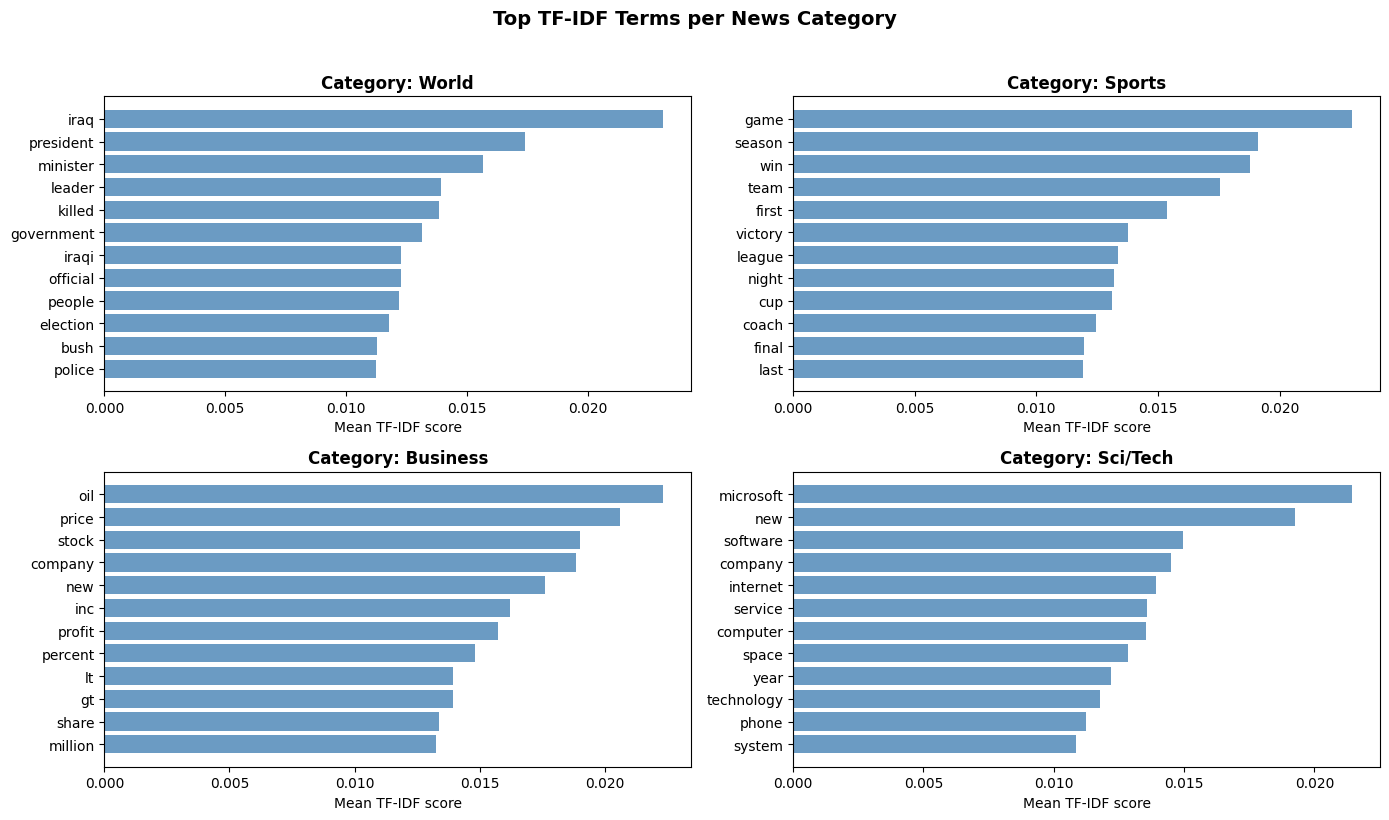

In [18]:
# Visualize top TF-IDF terms per category

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (cat_id, cat_name) in enumerate(zip(range(4), label_names)):
    mask    = sample_df['label'] == cat_id
    # Average TF-IDF score per term across documents in this category
    cat_vec = X_tfidf[mask.values].mean(axis=0).A1
    top_n   = 12
    top_idx = cat_vec.argsort()[-top_n:][::-1]
    terms   = tfidf_features[top_idx]
    scores  = cat_vec[top_idx]

    axes[idx].barh(terms[::-1], scores[::-1], color='steelblue', alpha=0.8)
    axes[idx].set_title(f'Category: {cat_name}', fontweight='bold')
    axes[idx].set_xlabel('Mean TF-IDF score')

plt.suptitle('Top TF-IDF Terms per News Category', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Word Embeddings with Word2Vec

Word embeddings represent words as dense vectors where semantically similar words cluster together. Word2Vec learns these from context windows in the corpus.

Two training algorithms:
- **CBOW** (Continuous Bag of Words): predict the center word from surrounding words
- **Skip-gram**: predict surrounding words from the center word (better for rare words)

In [19]:
# Prepare tokenized corpus for Word2Vec
tokenized_corpus = [text.split() for text in sample_df['clean_lemma']]

# Train a Word2Vec model
# vector_size : embedding dimensionality (50-300 is typical)
# window      : context window size
# min_count   : ignore words with fewer than this many occurrences
# sg=1        : use Skip-gram (sg=0 for CBOW)
# workers     : parallel threads

w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    workers=4,
    epochs=10,
    seed=42
)

vocab_size = len(w2v_model.wv)
print(f'Vocabulary size : {vocab_size:,}')
print(f'Embedding dim   : {w2v_model.wv.vector_size}')

Vocabulary size : 4,319
Embedding dim   : 100


In [20]:
# Semantic similarity: find the words most similar to a query term

for query in ['economy', 'football', 'software', 'election']:
    if query in w2v_model.wv:
        similar = w2v_model.wv.most_similar(query, topn=6)
        similar_words = [f"{w} ({s:.2f})" for w, s in similar]
        print(f'{query:<12}: {similar_words}')
    else:
        print(f'{query:<12}: not in vocabulary')

economy     : ['soaring (0.92)', 'stockpile (0.91)', 'index (0.91)', 'worry (0.90)', 'jobless (0.90)', 'easing (0.90)']
football    : ['coach (0.91)', 'striker (0.90)', 'mike (0.88)', 'squad (0.88)', 'liverpool (0.88)', 'english (0.88)']
software    : ['code (0.85)', 'vendor (0.82)', 'developer (0.82)', 'linux (0.80)', 'server (0.80)', 'flaw (0.79)']
election    : ['presidential (0.91)', 'poll (0.88)', 'ukraine (0.85)', 'candidate (0.82)', 'karzai (0.81)', 'opposition (0.81)']


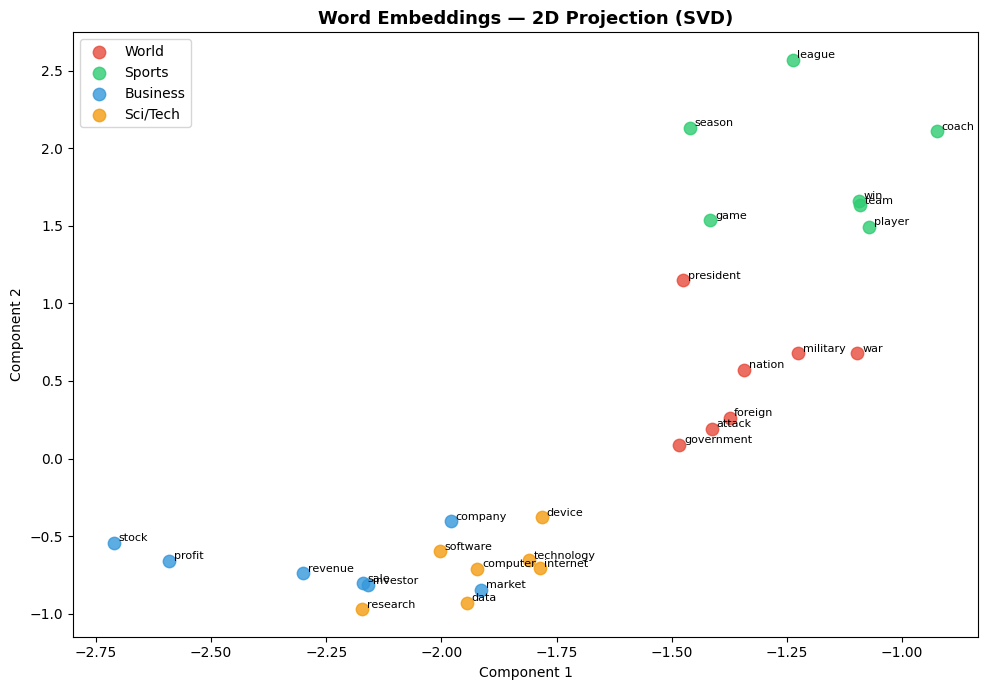

In [21]:
# Visualize word embeddings with 2D projection using SVD (a fast alternative to t-SNE)
# We'll look at terms from each news category to see if they cluster.

topic_words = {
    'World'    : ['government', 'military', 'war', 'president', 'foreign', 'nation', 'attack'],
    'Sports'   : ['game', 'team', 'player', 'season', 'win', 'coach', 'league'],
    'Business' : ['market', 'stock', 'company', 'profit', 'sale', 'revenue', 'investor'],
    'Sci/Tech' : ['technology', 'software', 'internet', 'computer', 'research', 'data', 'device'],
}

# Filter to words actually in vocabulary
filtered_words = {cat: [w for w in words if w in w2v_model.wv]
                  for cat, words in topic_words.items()}

all_words    = [w for words in filtered_words.values() for w in words]
all_labels   = [cat for cat, words in filtered_words.items() for w in words]
all_vectors  = np.array([w2v_model.wv[w] for w in all_words])

# Reduce to 2D
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(all_vectors)

# Plot
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
fig, ax = plt.subplots(figsize=(10, 7))

for (cat, _), color in zip(filtered_words.items(), colors):
    mask = [l == cat for l in all_labels]
    ax.scatter(coords[mask, 0], coords[mask, 1], label=cat, color=color, s=80, alpha=0.8)

for i, word in enumerate(all_words):
    ax.annotate(word, (coords[i, 0] + 0.01, coords[i, 1] + 0.01), fontsize=8)

ax.set_title('Word Embeddings — 2D Projection (SVD)', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
plt.tight_layout()
plt.show()

### 3.4 Contextual Embeddings — a Preview of BERT

Word2Vec gives each word a *single* fixed vector regardless of context. "Bank" means the same thing whether you're talking about a riverbank or a financial institution.

**BERT** (and other transformer models) produce *contextual* embeddings: the vector for "bank" changes depending on the surrounding sentence. This is why modern NLP models dramatically outperform classic approaches.

We won't fine-tune BERT today, but the code block below shows how you'd extract embeddings using `transformers`. Feel free to run it if you have a GPU.

In [ ]:
# PREVIEW (optional — requires: pip install transformers torch)
# Uncomment to run.

# from transformers import AutoTokenizer, AutoModel
# import torch

# model_name = 'bert-base-uncased'
# tokenizer  = AutoTokenizer.from_pretrained(model_name)
# bert_model = AutoModel.from_pretrained(model_name)

# sentence = "I went to the bank to deposit money."
# inputs   = tokenizer(sentence, return_tensors='pt')

# with torch.no_grad():
#     outputs = bert_model(**inputs)

# # outputs.last_hidden_state has shape (batch, seq_len, 768)
# # The [CLS] token (index 0) is commonly used as the sentence-level embedding.
# cls_embedding = outputs.last_hidden_state[:, 0, :]
# print('CLS embedding shape:', cls_embedding.shape)

print('BERT preview cell — uncomment to run if you have transformers installed.')

---
## Part 4 — Baseline Classifier: TF-IDF + Logistic Regression

Now we put it all together. A TF-IDF + Logistic Regression baseline is often surprisingly strong and runs in seconds — a good starting point before reaching for heavier models.

We'll use the full training set here to get more representative results.

In [22]:
# Preprocess the full training and test sets
# This takes a few minutes for 120k training examples.

print('Preprocessing full training set...')
train_df['clean'] = train_df['text'].apply(lambda t: preprocess(t, method='lemma'))

print('Preprocessing test set...')
test_df['clean'] = test_df['text'].apply(lambda t: preprocess(t, method='lemma'))

print('Done.')

Preprocessing full training set...
Preprocessing test set...
Done.


In [23]:
# Fit the TF-IDF vectorizer on training data only.
# Never fit on test data — that would leak future information into your model.

vectorizer = TfidfVectorizer(
    max_features=30_000,
    min_df=2,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(train_df['clean'])
X_test  = vectorizer.transform(test_df['clean'])     # transform only, not fit

y_train = train_df['label'].values
y_test  = test_df['label'].values

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')

X_train: (120000, 30000)
X_test : (7600, 30000)


In [ ]:
# Train a Logistic Regression classifier.
# C=5 is a mild regularization — you can tune this with cross-validation.
# max_iter=1000 ensures convergence on sparse high-dimensional data.

clf = LogisticRegression(C=5, max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=label_names))

In [ ]:
# Examine the most predictive features per class.
# The coefficients from Logistic Regression directly tell us which TF-IDF features
# push the model most strongly toward each class.

feature_names = vectorizer.get_feature_names_out()
top_n = 15

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for class_idx, (ax, label) in enumerate(zip(axes, label_names)):
    coef       = clf.coef_[class_idx]
    top_pos    = coef.argsort()[-top_n:][::-1]
    top_terms  = feature_names[top_pos]
    top_coefs  = coef[top_pos]

    ax.barh(top_terms[::-1], top_coefs[::-1], color='#2980b9', alpha=0.8)
    ax.set_title(f'{label} — top features', fontweight='bold')
    ax.set_xlabel('Coefficient value')

plt.suptitle('Most Predictive TF-IDF Features per Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Part 5 — Text EDA

Before building any model, exploratory analysis tells you what you're working with: are classes balanced? How long are documents? What's the vocabulary overlap between categories?

In [ ]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw counts
counts = train_df['label_name'].value_counts()
axes[0].bar(counts.index, counts.values, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].set_title('Class Distribution (Train)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# Document length distribution by class
train_df['token_count'] = train_df['clean'].apply(lambda x: len(x.split()))
for cat, color in zip(label_names, ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']):
    subset = train_df[train_df['label_name'] == cat]['token_count']
    axes[1].hist(subset, bins=40, alpha=0.5, label=cat, color=color)

axes[1].set_title('Token Count Distribution by Category', fontweight='bold')
axes[1].set_xlabel('Tokens per document (after preprocessing)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nAverage token count per category:')
print(train_df.groupby('label_name')['token_count'].describe()[['mean','std','min','max']].round(1))

In [ ]:
# Top 20 vocabulary terms per category (outside of generic words)
# This is a quick sanity check that the categories are actually distinct in vocabulary.

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (label, ax) in enumerate(zip(label_names, axes)):
    subset_text = ' '.join(train_df[train_df['label_name'] == label]['clean'])
    word_freq   = Counter(subset_text.split())
    common      = word_freq.most_common(20)
    words, freqs = zip(*common)

    ax.barh(list(words)[::-1], list(freqs)[::-1], color='#27ae60', alpha=0.8)
    ax.set_title(f'{label} — top words', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Top 20 Words per Category (after preprocessing)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Part 6 — Practice Exercises

Use these exercises to reinforce the concepts above. Work through them at your own pace.

In [ ]:
# Exercise 1: Custom Preprocessing
# -------------------------------------------------------
# Modify the preprocess() function to also:
#   (a) Expand contractions ("don't" -> "do not", "it's" -> "it is")
#   (b) Replace numbers with the token NUM instead of dropping them
#
# Hint: write a simple regex for numbers and a small dict for contractions.

# Your solution here...


In [ ]:
# Exercise 2: Preprocessing Strategy Comparison
# -------------------------------------------------------
# Train a Logistic Regression classifier using each preprocessing strategy:
#   - clean_none  (cleaned, no normalization)
#   - clean_lemma (cleaned + lemmatization)
#   - clean_stem  (cleaned + stemming)
#
# Compare test accuracy across strategies. Which one performs best on AG News?
# Explain why you think that is.

# Your solution here...


In [ ]:
# Exercise 3: Ngram Exploration
# -------------------------------------------------------
# Re-run the TF-IDF + Logistic Regression pipeline with three different ngram_range settings:
#   (1,1)  unigrams only
#   (1,2)  unigrams + bigrams
#   (2,2)  bigrams only
#
# Record accuracy for each. What does the best combination tell you about
# how news topics are distinguished in language?

# Your solution here...


In [ ]:
# Exercise 4: Word Embedding Analogies
# -------------------------------------------------------
# Word2Vec supports analogy queries:
#   "king" - "man" + "woman" ~ "queen"
#
# Try the following with your trained w2v_model (results depend on corpus size):
#   w2v_model.wv.most_similar(positive=['team', 'player'], negative=['game'], topn=5)
#   w2v_model.wv.most_similar(positive=['profit', 'loss'], topn=5)
#
# What do the results tell you about how well the model learned semantic relationships
# from news data?

# Your solution here...


In [ ]:
# Exercise 5 (Extension): Apply to Your Domain
# -------------------------------------------------------
# Pick a text dataset from your own domain (e.g., customer reviews, medical notes,
# support tickets, legal documents).
#
# You can find datasets on Hugging Face: https://huggingface.co/datasets
#
# Steps:
#   1. Load the dataset
#   2. Run EDA: class balance, document length, top vocabulary terms
#   3. Apply the preprocessing pipeline (adjust stopwords for your domain)
#   4. Build a TF-IDF + Logistic Regression baseline
#   5. Report accuracy and note which classes are hardest to distinguish

# Suggested datasets:
#   load_dataset('imdb')                  -> sentiment analysis
#   load_dataset('trec')                  -> question classification
#   load_dataset('banking77')             -> banking intent classification
#   load_dataset('emotion')               -> emotion detection

# Your solution here...


---
## Project Assignment

Select an NLP task from the options below and build a baseline system. Submit a notebook that includes:

**Domain options:**
- Sentiment analysis (product reviews, tweets)
- News categorization
- Customer feedback / support ticket classification
- Chatbot intent detection
- Document summarization (extractive)
- Question answering (retrieval-based)

**Deliverables:**
1. **Dataset selection** — source a text dataset relevant to your domain (Hugging Face Hub recommended)
2. **Text EDA** — analyze document length distribution, vocabulary size, class balance, and top terms per class
3. **Preprocessing pipeline** — justify your choices (why these stopwords? stem vs lemma?)
4. **Baseline model** — TF-IDF + Logistic Regression (or Naive Bayes)
5. **Error analysis** — look at 10–20 misclassified examples and hypothesize why they were wrong
6. **Next steps** — what would you try to improve the model? (better features, different model, more data?)

---

## When to Use Which Representation

| Task | Recommended Approach |
|------|---------------------|
| Short text classification (tweets, headlines) | TF-IDF with bigrams |
| Long document classification | TF-IDF + dimensionality reduction (SVD/LSA) |
| Semantic similarity | Word embeddings (Word2Vec, GloVe) or sentence-BERT |
| Sequence tagging (NER, POS) | Contextual embeddings (BERT) |
| Production at scale | TF-IDF baselines first; upgrade only if needed |

> **Rule of thumb:** Always run a TF-IDF baseline first. It's fast, interpretable, and sets a performance floor. If it reaches your accuracy target, ship it.